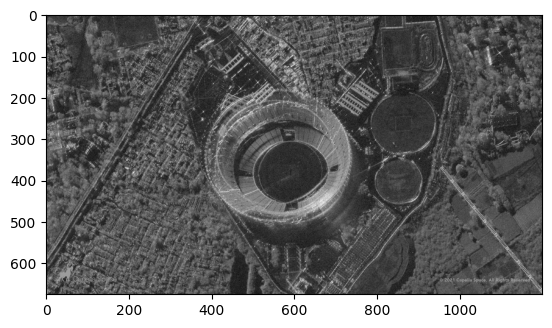

In [3]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
import copy
from skimage.metrics import structural_similarity, mean_squared_error

image = cv2.imread('sar_1.jpg')
image_gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

plt.imshow(image_gray, cmap="gray")

# ДЗ 2
# Зашумить изображение при помощи шума гаусса, постоянного шума.
# Протестировать медианный фильтр, фильтр гаусса, билатериальный фильтр, фильтр нелокальных средних с различными параметрами.
# Выяснить, какой фильтр показал лучший результат фильтрации шума.

In [4]:
def evaluate(original, filtered, name=""):
    mse = mean_squared_error(original, filtered)
    (ssim, _) = structural_similarity(original, filtered, full=True)
    print(f"{name:35s} | MSE = {mse:10.3f} | SSIM = {ssim:.4f}")
    return mse, ssim

Gaussian noise                      | MSE =   4230.673 | SSIM = 0.1870


(np.float64(4230.673058024691), np.float64(0.1869926680003536))

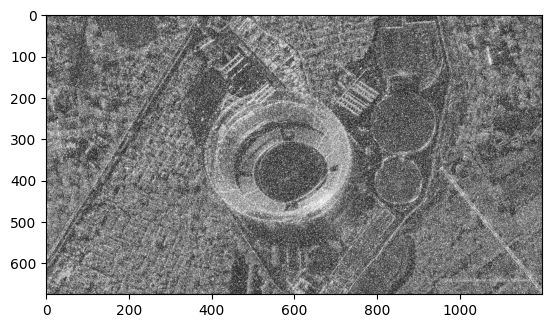

In [5]:
# Шум Гаусса
mean = 0
stddev = 100
noise_gauss = np.zeros(image_gray.shape, np.uint8)
cv2.randn(noise_gauss, mean, stddev)

image_noise_gauss = cv2.add(image_gray, noise_gauss)

plt.imshow(image_noise_gauss, cmap="gray")
evaluate(image_gray, image_noise_gauss, "Gaussian noise")

Uniform noise                       | MSE =    842.268 | SSIM = 0.4107


(np.float64(842.2684641975309), np.float64(0.4106736380032321))

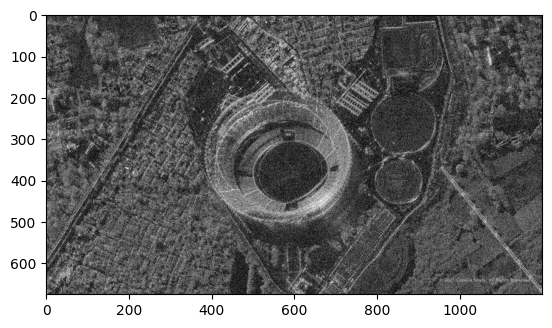

In [6]:
# Равномерный
A = 50
noise = np.zeros(image_gray.shape, dtype=np.uint8)
cv2.randu(noise, 0, 2 * A + 1)
noise = noise.astype(np.int16) - A
image_sp = np.clip(image_gray.astype(np.int16) + noise, 0, 255).astype(np.uint8)

plt.imshow(image_sp, cmap="gray")
evaluate(image_gray, image_sp, "Uniform noise")

In [7]:
# Задание 2
for k in [3, 5, 7]:
    img_med = cv2.medianBlur(image_noise_gauss, k)
    evaluate(image_gray, img_med, f"Gauss + medianBlur k={k}")


for k in [(3, 3), (5, 5), (7, 7)]:
    img_g = cv2.GaussianBlur(image_noise_gauss, k, 0)
    evaluate(image_gray, img_g, f"Gauss + GaussianBlur {k}")

for sigma in [10, 30, 50]:
    img_g = cv2.GaussianBlur(image_noise_gauss, (5, 5), sigma)
    evaluate(image_gray, img_g, f"Gauss + GaussianBlur sigma={sigma}")


for d, sc, ss in [(5, 30, 30), (9, 75, 75), (9, 150, 150), (15, 200, 200)]:
    img_b = cv2.bilateralFilter(image_noise_gauss, d, sc, ss)
    evaluate(image_gray, img_b, f"Gauss + bilateral d={d},sc={sc},ss={ss}")


for h in [5, 10, 20, 30]:
    img_nlm = cv2.fastNlMeansDenoising(image_noise_gauss, h=h)
    evaluate(image_gray, img_nlm, f"Gauss + NLM h={h}")

Gauss + medianBlur k=3              | MSE =   1038.045 | SSIM = 0.4282
Gauss + medianBlur k=5              | MSE =    706.031 | SSIM = 0.4702
Gauss + medianBlur k=7              | MSE =    682.569 | SSIM = 0.4336
Gauss + GaussianBlur (3, 3)         | MSE =   1903.453 | SSIM = 0.4403
Gauss + GaussianBlur (5, 5)         | MSE =   1764.642 | SSIM = 0.4860
Gauss + GaussianBlur (7, 7)         | MSE =   1721.196 | SSIM = 0.4925
Gauss + GaussianBlur sigma=10       | MSE =   1754.647 | SSIM = 0.4406
Gauss + GaussianBlur sigma=30       | MSE =   1754.647 | SSIM = 0.4406
Gauss + GaussianBlur sigma=50       | MSE =   1754.647 | SSIM = 0.4406
Gauss + bilateral d=5,sc=30,ss=30   | MSE =   3705.772 | SSIM = 0.1901
Gauss + bilateral d=9,sc=75,ss=75   | MSE =   1837.548 | SSIM = 0.3145
Gauss + bilateral d=9,sc=150,ss=150 | MSE =   1547.905 | SSIM = 0.4413
Gauss + bilateral d=15,sc=200,ss=200 | MSE =   1670.613 | SSIM = 0.3546
Gauss + NLM h=5                     | MSE =   4230.673 | SSIM = 0.1870
Gauss

In [10]:

for k in [3, 5, 7]:
    img_med = cv2.medianBlur(image_sp, k)
    evaluate(image_gray, img_med, f"Uniform + medianBlur k={k}")

img_g = cv2.GaussianBlur(image_sp, (5, 5), 0)
evaluate(image_gray, img_g, "Uniform + GaussianBlur 5x5")

img_b = cv2.bilateralFilter(image_sp, 9, 75, 75)
evaluate(image_gray, img_b, "Uniform + bilateral 9,75,75")

img_nlm = cv2.fastNlMeansDenoising(image_sp, h=20)
evaluate(image_gray, img_nlm, "Uniform + NLM h=20")

Uniform + medianBlur k=3            | MSE =    316.541 | SSIM = 0.5393
Uniform + medianBlur k=5            | MSE =    286.412 | SSIM = 0.5070
Uniform + medianBlur k=7            | MSE =    311.468 | SSIM = 0.4519
Uniform + GaussianBlur 5x5          | MSE =    173.921 | SSIM = 0.6814
Uniform + bilateral 9,75,75         | MSE =    210.088 | SSIM = 0.6091
Uniform + NLM h=20                  | MSE =    298.985 | SSIM = 0.6032


(np.float64(298.9852728395062), np.float64(0.603229577944292))

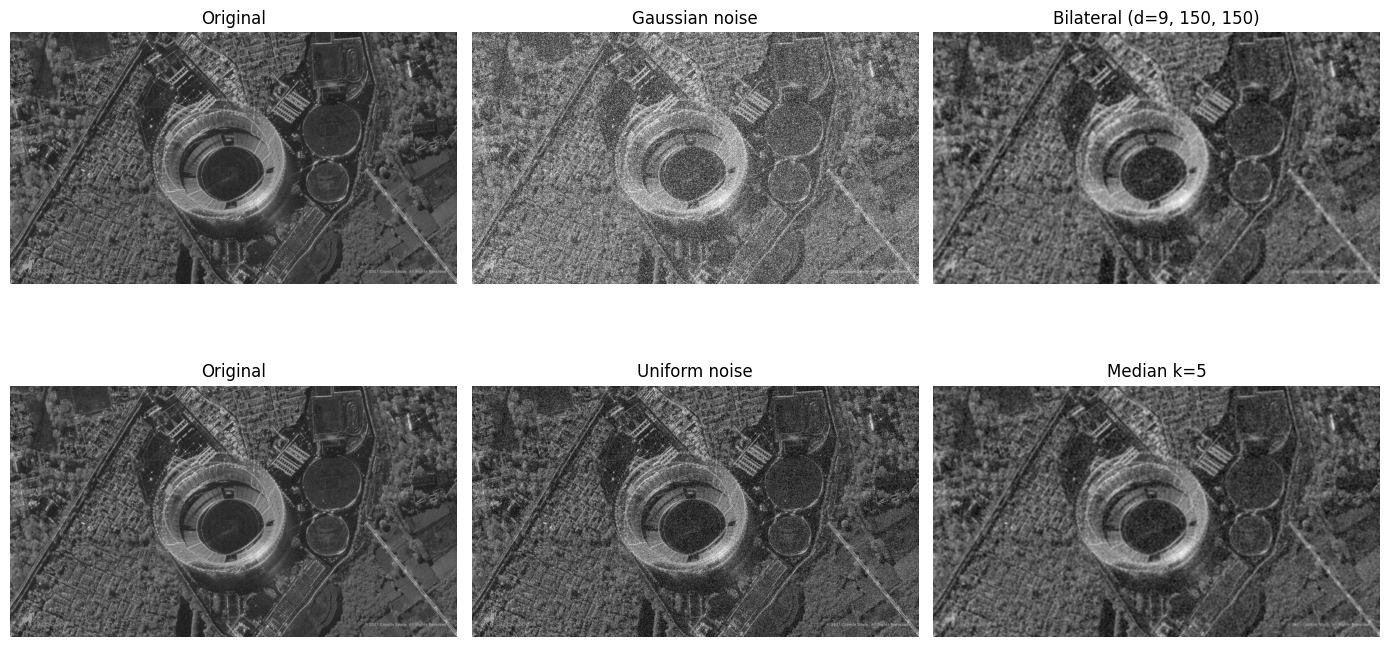

In [11]:
# Задание 3
best_gauss = cv2.bilateralFilter(image_noise_gauss, 9, 150, 150)
best_sp = cv2.medianBlur(image_sp, 5)

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes[0, 0].imshow(image_gray, cmap="gray"); axes[0, 0].set_title("Original")
axes[0, 1].imshow(image_noise_gauss, cmap="gray"); axes[0, 1].set_title("Gaussian noise")
axes[0, 2].imshow(best_gauss, cmap="gray"); axes[0, 2].set_title("Bilateral (d=9, 150, 150)")
axes[1, 0].imshow(image_gray, cmap="gray"); axes[1, 0].set_title("Original")
axes[1, 1].imshow(image_sp, cmap="gray"); axes[1, 1].set_title("Uniform noise")
axes[1, 2].imshow(best_sp, cmap="gray"); axes[1, 2].set_title("Median k=5")
for ax in axes.ravel():
    ax.axis("off")
plt.tight_layout()
plt.show()

Для гауссова шума наилучший результат показали билатеральный фильтр и фильтр нелокальных средних
Для равномерного шума лучше всего подходит медианный фильтр